In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/subhajournal/phishingemails/Phishing_Email.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/subhajournal/phishingemails/Phishing_Email.csv")
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
df = df.rename(columns={
    "Unnamed" : "index",
    "Email Text": "text",
    "Email Type": "label"
})

In [4]:
df.columns

Index(['Unnamed: 0', 'text', 'label'], dtype='object')

In [5]:
df.drop(columns = ['Unnamed: 0'], inplace=True)
df.columns

Index(['text', 'label'], dtype='object')

`Data Description`

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    18634 non-null  object
 1   label   18650 non-null  object
dtypes: object(2)
memory usage: 291.5+ KB


In [7]:
print(df["label"].unique())

['Safe Email' 'Phishing Email']


In [8]:
print(df["label"].value_counts())

label
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64


In [9]:
#convert labels to Numeric
df["label"] = df["label"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    18634 non-null  object
 1   label   18650 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 291.5+ KB


In [11]:
#Dataset shape
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 18650
Columns : 2


`Data Cleaning`

In [12]:
#check missing values
df.isnull().sum()

text     16
label     0
dtype: int64

In [13]:
#remove missing values
df.dropna(inplace=True)

In [14]:
#duplicate records
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 1096


In [15]:
#remove duplicate records
df.drop_duplicates(inplace=True)

In [16]:
df['label'].value_counts()

label
0    10980
1     6558
Name: count, dtype: int64

`EDA`

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

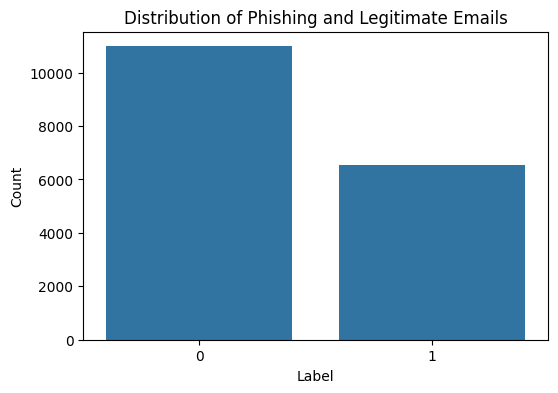

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Distribution of Phishing and Legitimate Emails")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [19]:
#Email length
df['email_length'] = df['text'].apply(len)

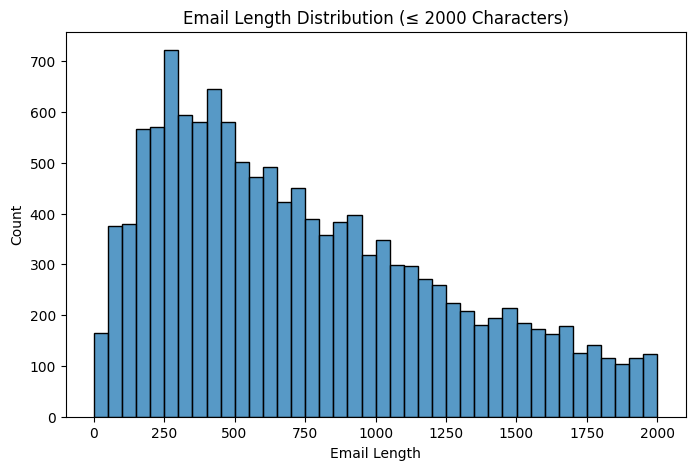

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(df[df['email_length'] <= 2000]['email_length'], bins=40)

plt.title("Email Length Distribution (≤ 2000 Characters)")
plt.xlabel("Email Length")

plt.show()

In [21]:
#Word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

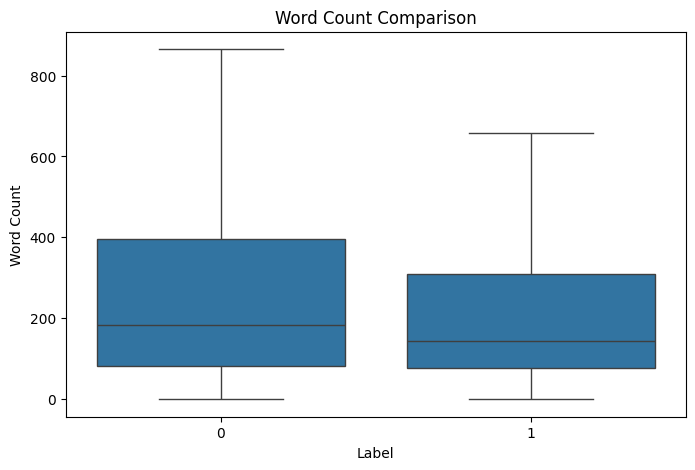

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='label',
    y='word_count',
    data=df,
    showfliers=False
)

plt.title("Word Count Comparison")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.show()

In [23]:
df.describe()

,label,email_length,word_count
count,17538.000000,1.753800e+04,1.753800e+04
mean,0.373931,2.861826e+03,5.562730e+02
std,0.483859,1.287050e+05,2.664518e+04
min,0.000000,1.000000e+00,0.000000e+00
25%,0.000000,4.342500e+02,8.000000e+01
50%,0.000000,9.160000e+02,1.670000e+02
75%,1.000000,1.945750e+03,3.677500e+02
max,1.000000,1.703669e+07,3.527576e+06


`NLP Preprocessing`

In [24]:
import re
import string

import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [25]:
#Download NLTK Resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [26]:
#CReate Stopword List
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [27]:
#Remove HTML Tages
def remove_html(text):
    return re.sub(r'<.*?>', '', str(text))

#Remove URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

#Remove Email Addresses
def remove_email(text):
    return re.sub(r'\S+@\S+', '', text)

#Convert to Lower Case
def to_lower(text):
    return text.lower()

#Remove Numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

#Remove Punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

#Remove extra spaces
def remove_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

#Tokenization
def tokenize(text):
    return word_tokenize(text)

#Remove stopwords
def remove_stopwords(words):
    return [word for word in words if word not in stop_words]

#Lemmatization
def lemmatize(words):
    return [lemmatizer.lemmatize(word) for word in words]


In [28]:
#Complete cleanning function
def clean_text(text):

    text = remove_html(text)

    text = remove_urls(text)

    text = remove_email(text)

    text = to_lower(text)

    text = remove_numbers(text)

    text = remove_punctuation(text)

    text = remove_spaces(text)

    words = tokenize(text)

    words = remove_stopwords(words)

    words = lemmatize(words)

    return " ".join(words)

In [29]:
df.columns

Index(['text', 'label', 'email_length', 'word_count'], dtype='object')

In [30]:
#Apply Cleaning
df["clean_text"] = df["text"].apply(clean_text)

In [31]:
#Compare Original vs Cleaned
df[['text','clean_text']].head(5)

,text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",disc uniformitarianism sex lang dick hudson ob...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term name im...
2,re : equistar deal tickets are you still avail...,equistar deal ticket still available assist ro...
3,\nHello I am your hot lil horny toy.\n I am...,hello hot lil horny toy one dream open minded ...
4,software at incredibly low prices ( 86 % lower...,software incredibly low price lower drapery se...


In [32]:
#Check empty Rows
df[df['clean_text']==""]

,text,label,email_length,word_count,clean_text
3889,\n4623\n,1,6,1,
9427,http://www.post-gazette.com/columnists/2002090...,0,57,1,
9605,\n,1,1,0,


In [33]:
#Remove empty rows
df = df[df['clean_text']!=""]

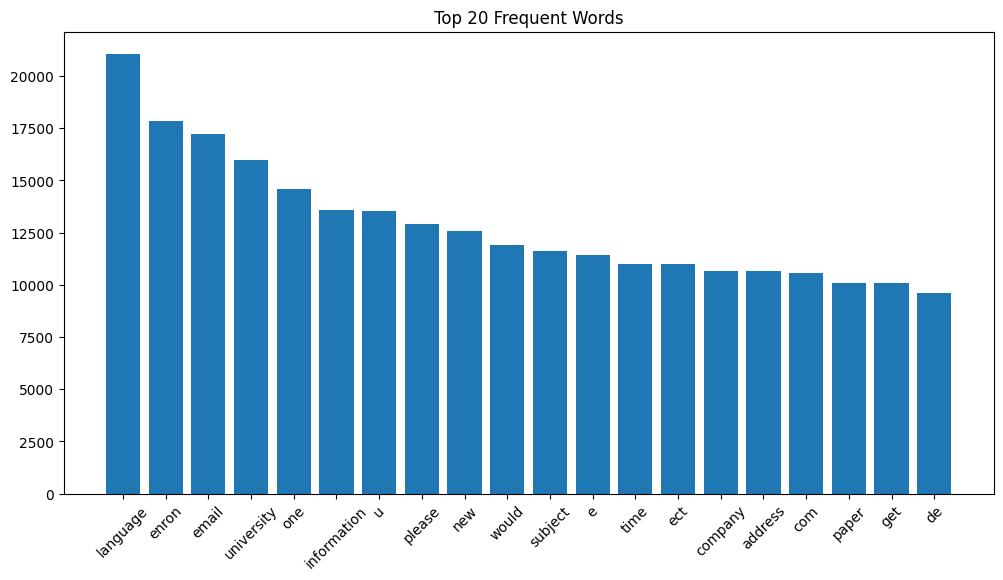

In [34]:
#Top 20 Most Frequent WOrds
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [i[0] for i in common_words]

counts = [i[1] for i in common_words]

plt.figure(figsize=(12,6))

plt.bar(words, counts)

plt.xticks(rotation=45)

plt.title("Top 20 Frequent Words")
plt.show()

`Feature engineering`

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [36]:
df.columns

Index(['text', 'label', 'email_length', 'word_count', 'clean_text'], dtype='object')

In [37]:
#Create Metadata Features
#URL Count
def url_count(text):
    return len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

#Digit Count
def digit_count(text):
    return sum(c.isdigit() for c in str(text))

#Uppercase Count
def uppercase_count(text):
    return sum(c.isupper() for c in str(text))

#Special Character Count
def special_count(text):
    return len(re.findall(r'[!@#$%^&*(),.?":{}|<>]', str(text)))

#Character Count
def char_count(text):
    return len(str(text))

#Words Count
def word_count(text):
    return len(str(text).split())

In [38]:
#Apply Metdata Extraction
df['url_count'] = df['text'].apply(url_count)

df['digit_count'] = df['text'].apply(digit_count)

df['uppercase_count'] = df['text'].apply(uppercase_count)

df['special_count'] = df['text'].apply(special_count)

df['char_count'] = df['text'].apply(char_count)

df['word_count'] = df['text'].apply(word_count)

In [39]:
df.columns

Index(['text', 'label', 'email_length', 'word_count', 'clean_text',
       'url_count', 'digit_count', 'uppercase_count', 'special_count',
       'char_count'],
      dtype='object')

In [40]:
#TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [41]:
#Convert TExt into Vectors
X_text = tfidf.fit_transform(df["clean_text"])

In [42]:
#View Shape
print(X_text.shape)

(17535, 5000)


In [43]:
#Convert Meatadata to Matrix
metadata = df[
    [
        "url_count",
        "digit_count",
        "uppercase_count",
        "special_count",
        "char_count",
        "word_count"
    ]
]

In [44]:
#Combine TF-IDF + Metadata
from scipy.sparse import hstack

X = hstack([X_text, metadata.values])

In [45]:
#Target Variable
y = df['label']

In [46]:
#Final Shape
print(X.shape)
print(y.shape)

(17535, 5006)
(17535,)


In [47]:
#Top TF-IDF Words
feature_names = tfidf.get_feature_names_out()

idf_scores = tfidf.idf_

tfidf_df = pd.DataFrame({
    "Word": feature_names,
    "IDF": idf_scores
})

tfidf_df.head()

,Word,IDF
0,aa,6.127620
1,aaa,7.439807
2,ab,6.567319
3,ability,4.543500
4,able,3.788221


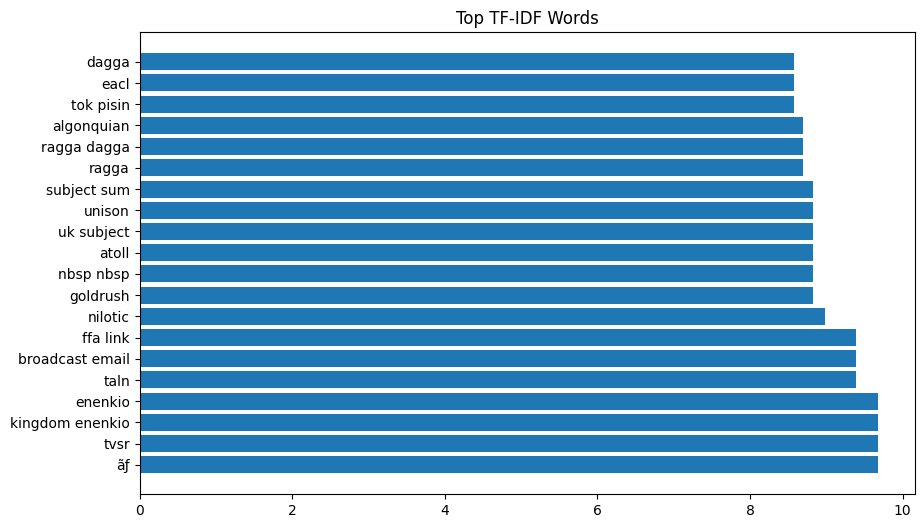

In [48]:
#Top 20 Important Words
top = tfidf_df.sort_values(
    by="IDF",
    ascending=False
).head(20)

plt.figure(figsize=(10,6))

plt.barh(top["Word"], top["IDF"])

plt.title("Top TF-IDF Words")
plt.show()

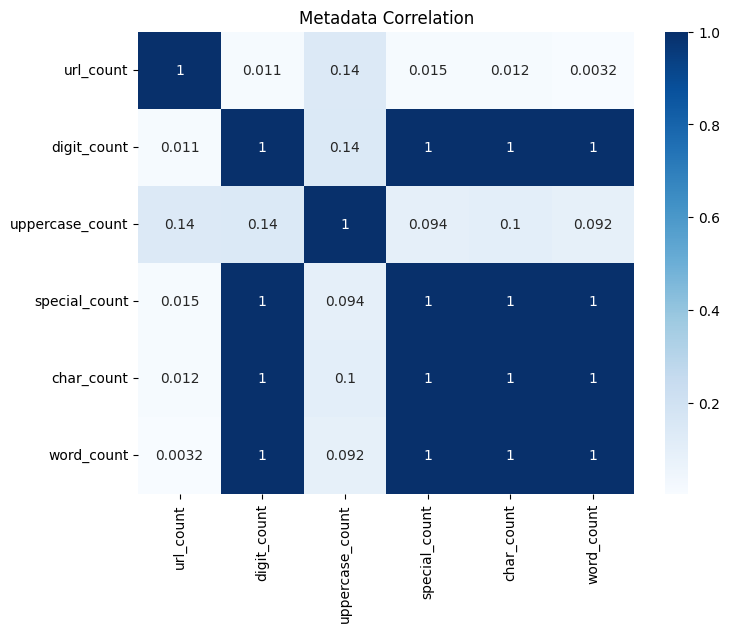

In [49]:
#Metadata correlation
meta = df[
[
"url_count",
"digit_count",
"uppercase_count",
"special_count",
"char_count",
"word_count"
]]

plt.figure(figsize=(8,6))

sns.heatmap(meta.corr(),
            annot=True,
            cmap="Blues")

plt.title("Metadata Correlation")
plt.show()

`Model Development`


In [50]:

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

In [51]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
#Check dataset shape
print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (14028, 5006)
Testing Samples : (3507, 5006)


Logistic Regression

In [53]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [54]:
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [55]:
lr_pred = lr.predict(X_test)

Naive Bayes

In [56]:
nb = MultinomialNB()

In [57]:
nb.fit(X_train,y_train)

MultinomialNB()

In [58]:
nb_pred = nb.predict(X_test)

Random Forest

In [59]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [60]:
rf.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [61]:
rf_pred = rf.predict(X_test)

Nural Network

In [62]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)


In [63]:
mlp.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(max_iter=20, random_state=42)

In [64]:
mlp_pred = mlp.predict(X_test)

In [65]:
print("Logistic Regression :", len(lr_pred))

print("Naive Bayes :", len(nb_pred))

print("Random Forest :", len(rf_pred))

print("Neural Network :", len(mlp_pred))

Logistic Regression : 3507
Naive Bayes : 3507
Random Forest : 3507
Neural Network : 3507


`Model Evaluation`

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [67]:
#Get prediction Probabilitis for ROC-AUC
lr_prob = lr.predict_proba(X_test)[:,1]

nb_prob = nb.predict_proba(X_test)[:,1]

rf_prob = rf.predict_proba(X_test)[:,1]

mlp_prob = mlp.predict_proba(X_test)[:,1]

In [68]:
#Create Evaluation Function
def evaluate_model(name, y_true, y_pred, y_prob):

    print("="*50)
    print("Model: ",name)
    print("="*50)

    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.2f}")
    print(f"Precision : {precision_score(y_true, y_pred):.2f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.2f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred):.2f}")
    print(f"ROC AUC   : {roc_auc_score(y_true, y_prob):.2f}")


    print()

    print(classification_report(y_true,y_pred))

`Evaluate Every Model`

In [69]:
#Logistic Regression
evaluate_model(
    "LogisticRegression",
    y_test,
    lr_pred,
    lr_prob
)
evaluate_model(
    "Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)
evaluate_model(
    "Neural Network",
    y_test,
    mlp_pred,
    mlp_prob
)

Model:  LogisticRegression
Accuracy  : 0.97
Precision : 0.96
Recall    : 0.96
F1 Score  : 0.96
ROC AUC   : 0.99

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2196
           1       0.96      0.96      0.96      1311

    accuracy                           0.97      3507
   macro avg       0.97      0.97      0.97      3507
weighted avg       0.97      0.97      0.97      3507

Model:  Naive Bayes
Accuracy  : 0.55
Precision : 0.38
Recall    : 0.35
F1 Score  : 0.36
ROC AUC   : 0.56

              precision    recall  f1-score   support

           0       0.63      0.66      0.65      2196
           1       0.38      0.35      0.36      1311

    accuracy                           0.55      3507
   macro avg       0.51      0.51      0.51      3507
weighted avg       0.54      0.55      0.54      3507

Model:  Random Forest
Accuracy  : 0.97
Precision : 0.96
Recall    : 0.96
F1 Score  : 0.96
ROC AUC   : 1.00

              preci

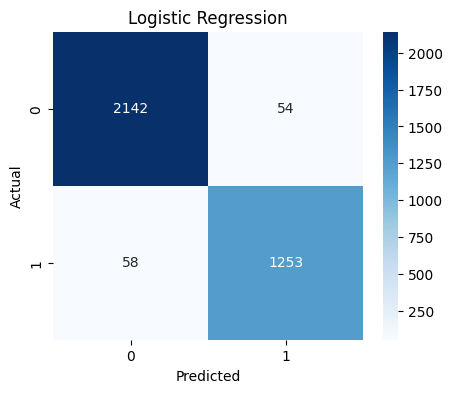

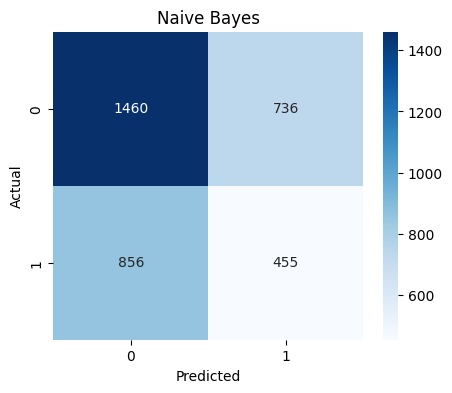

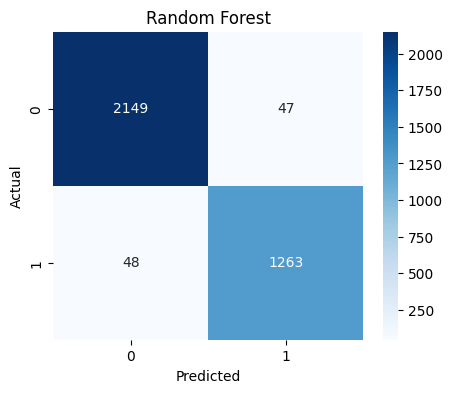

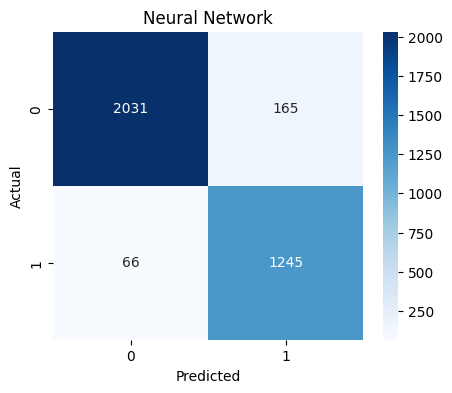

In [70]:
#Confusion Metrics
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "Random Forest": rf_pred,
    "Neural Network": mlp_pred
}

for model_name, pred in models.items():

    cm = confusion_matrix(y_test,pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(model_name)

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

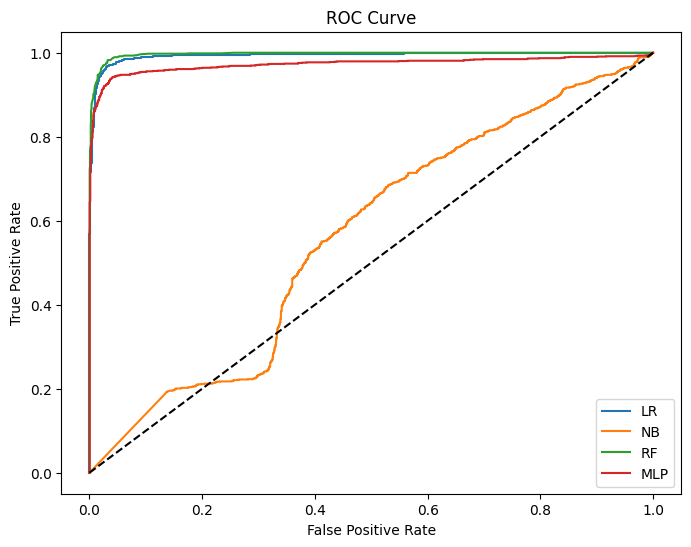

In [71]:
#ROC Curve
plt.figure(figsize=(8,6))

for name, prob in zip(
    ["LR","NB","RF","MLP"],
    [lr_prob,nb_prob,rf_prob,mlp_prob]
):

    fpr,tpr,_ = roc_curve(y_test,prob)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

`Comparison Table`

In [72]:
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
])

In [73]:
models = [
("Logistic Regression",lr,lr_pred,lr_prob),
("Naive Bayes",nb,nb_pred,nb_prob),
("Random Forest",rf,rf_pred,rf_prob),
("Neural Network",mlp,mlp_pred,mlp_prob)
]

for name,model,pred,prob in models:

    results.loc[len(results)] = [

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred),

        roc_auc_score(y_test,prob)

    ]

In [74]:
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.968064,0.958684,0.955759,0.957219,0.992860
1,Naive Bayes,0.546051,0.382032,0.347063,0.363709,0.563661
2,Random Forest,0.972911,0.964122,0.963387,0.963754,0.996727
3,Neural Network,0.934132,0.882979,0.949657,0.915105,0.972583


`Testing`

In [75]:
# Dictionary of trained models
models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf,
    "Neural Network": mlp
}

# Find the row with the highest accuracy
best_row = results.loc[results["Accuracy"].idxmax()]

# Best model name
best_model_name = best_row["Model"]

print("Best Model :", best_model_name)

# Display evaluation metrics for the best model
print(best_row)

# Retrieve the trained model object
best_model = models[best_model_name]

print(type(best_model))

Best Model : Random Forest
Model        Random Forest
Accuracy          0.972911
Precision         0.964122
Recall            0.963387
F1                0.963754
ROC-AUC           0.996727
Name: 2, dtype: object
<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [76]:
#Metadata Extraction function
def metadata_features(text):

    url_count = len(re.findall(r'http[s]?://\S+|www\.\S+', str(text)))

    digit_count = sum(c.isdigit() for c in text)

    uppercase_count = sum(c.isupper() for c in text)

    special_count = len(re.findall(r'[!@#$%^&*(),.?":{}|<>]', text))

    char_count = len(text)

    word_count = len(text.split())

    return np.array([
        url_count,
        digit_count,
        uppercase_count,
        special_count,
        char_count,
        word_count
    ]).reshape(1,-1)

In [77]:
#Prediction function
def predict_email(email_text):

    # Clean email
    cleaned = clean_text(email_text)

    # TF-IDF
    tfidf_vector = tfidf.transform([cleaned])

    # Metadata
    meta = metadata_features(email_text)

    # Combine features
    features = hstack([tfidf_vector, meta])

    # Prediction
    prediction = model.predict(features)[0]

    # Probability
    probability = model.predict_proba(features)[0]

    confidence = max(probability) * 100

    label = "Phishing" if prediction == 1 else "Legitimate"

    print("="*60)
    print("Prediction :", label)
    print(f"Confidence : {confidence:.2f}%")
    print("="*60)

    return prediction

In [78]:
#Test Example 1 : Phishing
email = """
Dear Customer,

Your bank account has been suspended.

Please verify your account immediately by clicking the link below.

https://paypal-security-login.xyz

Failure to verify within 24 hours will permanently suspend your account.

Regards,
Security Team
"""

predict_email(email)

Prediction : Phishing
Confidence : 99.71%


np.int64(1)

In [79]:
#Test Example 2 : Legitimate
email = """
Hi Manish,

Tomorrow's project meeting will begin at 10 AM in Lab 302.

Please bring your presentation slides.

Thanks.

Professor
"""

predict_email(email)

Prediction : Legitimate
Confidence : 95.18%


np.int64(0)